# Fase de Análisis Exploratorio de Datos

## Importación de librerías y configuraciones

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================
# CONFIGURACIÓN DE PANDAS
# ============================

# Mostrar todas las columnas del DataFrame
pd.set_option('display.max_columns', None)

# Ajustar el ancho de la salida al tamaño de la ventana
pd.set_option('display.width', None)

# Mostrar el contenido completo de las celdas
pd.set_option('display.max_colwidth', None)

# Mostrar los números con dos decimales
pd.options.display.float_format = '{:,.2f}'.format

# ============================
# CONFIGURACIÓN DE GRÁFICOS
# ============================

# Tamaño por defecto de las figuras
plt.rcParams['figure.figsize'] = (10, 6)


## Carga de datos

In [ ]:
# Se importan los datos

df_ventas = pd.read_csv(
    "../Datos_transformados/df_ventas.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"])

In [6]:
order_payments = pd.read_csv("../Datos_transformados/order_payments_clean.csv")

In [7]:
order_reviews = pd.read_csv("../Datos_transformados/order_reviews_clean.csv",
    parse_dates=["review_creation_date"])

In [8]:
df_marketing = pd.read_csv("../Datos_transformados/df_marketing.csv",
    parse_dates=[
        "first_contact_date",
        "won_date"])

In [9]:
# Se comprueban las dimensiones de los datasets

print("df_ventas:", df_ventas.shape)
print("order_payments:", order_payments.shape)
print("order_reviews:", order_reviews.shape)
print("df_marketing:", df_marketing.shape)

df_ventas: (112650, 19)
order_payments: (103886, 4)
order_reviews: (99224, 4)
df_marketing: (8000, 9)


In [ ]:
# Comprobar los tipos de las columnas de fecha

print(df_ventas.dtypes[
    ["order_purchase_timestamp",
     "order_delivered_customer_date",
     "order_estimated_delivery_date"]])

print(order_reviews.dtypes[
    ["review_creation_date"]])

print(df_marketing.dtypes[
    ["first_contact_date",
     "won_date"]])

order_purchase_timestamp         datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object
review_creation_date    datetime64[us]
dtype: object
first_contact_date    datetime64[us]
won_date              datetime64[us]
dtype: object


## Objetivo del Análisis Exploratorio de Datos (EDA)

### Analizar el rendimiento comercial del marketplace Olist para identificar patrones de venta, comportamiento de clientes y vendedores, factores relacionados con la satisfacción del cliente y el proceso de captación de vendedores mediante datos de marketing.

### Bloque 1. Evolución del negocio

1. ¿Cómo ha evolucionado la actividad comercial del marketplace a lo largo del tiempo?

Para empezar se crean variables temporales que nos faciliten el análisis:

In [11]:
ventas_tiempo = df_ventas.copy()

In [12]:
ventas_tiempo["year"] = ventas_tiempo["order_purchase_timestamp"].dt.year

In [13]:
ventas_tiempo["month"] = ventas_tiempo["order_purchase_timestamp"].dt.month

In [14]:
ventas_tiempo["month"] = ventas_tiempo["order_purchase_timestamp"].dt.month

In [15]:
ventas_tiempo["year_month"] = ventas_tiempo["order_purchase_timestamp"].dt.to_period("M")

In [16]:
ventas_tiempo["sales_amount"] = (ventas_tiempo["price"] + ventas_tiempo["freight_value"])

In [22]:
# Tabla resumen: dado que el df esta por línea de producto y no por pedido, en esta tabla agrupamos los order_id y sumamos los ingresos de venta creados:

evolucion_mensual = ventas_tiempo.groupby("year_month").agg(
    pedidos = ("order_id", "nunique"), 
    ventas = ("sales_amount", "sum")).reset_index()

evolucion_mensual

,year_month,pedidos,ventas
0,2016-09,3,354.75
1,2016-10,308,"56,808.84"
2,2016-12,1,19.62
3,2017-01,789,"137,188.49"
4,2017-02,1733,"286,280.62"
5,2017-03,2641,"432,048.59"
6,2017-04,2391,"412,422.24"
7,2017-05,3660,"586,190.95"
8,2017-06,3217,"502,963.04"
9,2017-07,3969,"584,971.62"


En la tabla podemos ver que 2016 y septiembre de 2018 tienen muy pocos pedidos, habrá que analizar estos valores extremos ya que no se pueden interpretar como una tendencia.

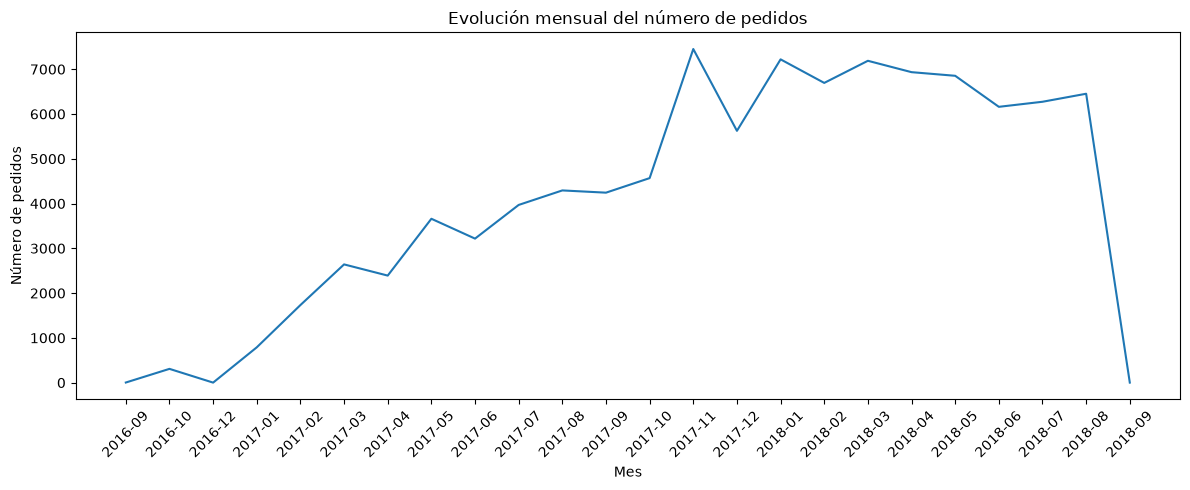

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    evolucion_mensual["year_month"].astype(str),
    evolucion_mensual["pedidos"]
)

plt.title("Evolución mensual del número de pedidos")
plt.xlabel("Mes")
plt.ylabel("Número de pedidos")
plt.xticks(rotation=45) # giramos etiquetas para que sean visibles
plt.tight_layout() # ajusta los elementos para que queden dentro del gráfico 
plt.show()

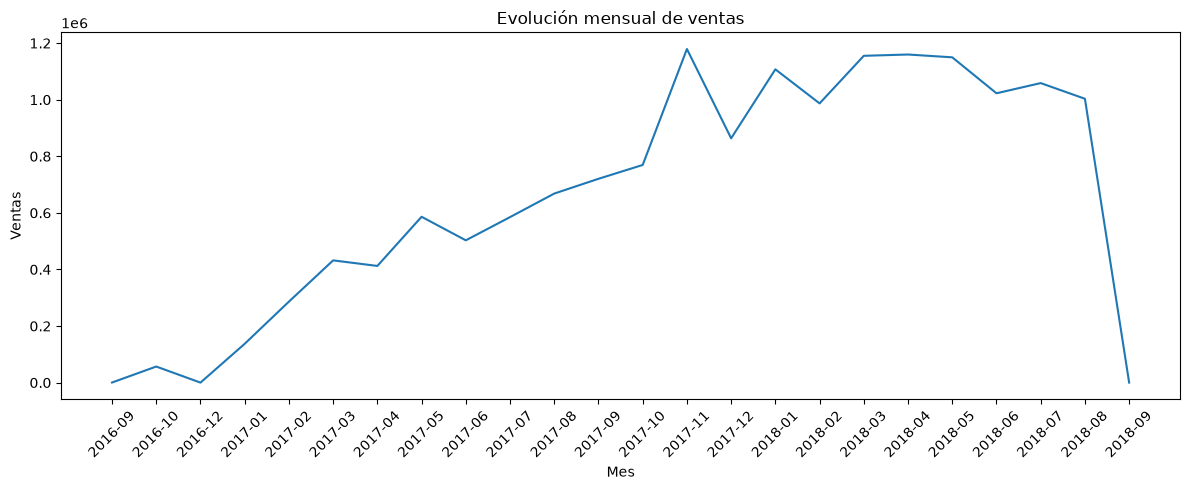

In [25]:
# Gráfico de ventas

plt.figure(figsize=(12, 5))

plt.plot(
    evolucion_mensual["year_month"].astype(str),
    evolucion_mensual["ventas"]
)

plt.title("Evolución mensual de ventas")
plt.xlabel("Mes")
plt.ylabel("Ventas")
plt.xticks(rotation=45) # giramos etiquetas para que sean visibles
plt.tight_layout() # ajusta los elementos para que queden dentro del gráfico 
plt.show()

In [23]:
# Importe medio por pedido

evolucion_mensual["ticket_medio"] = evolucion_mensual["ventas"] / evolucion_mensual["pedidos"]
evolucion_mensual

,year_month,pedidos,ventas,ticket_medio
0,2016-09,3,354.75,118.25
1,2016-10,308,"56,808.84",184.44
2,2016-12,1,19.62,19.62
3,2017-01,789,"137,188.49",173.88
4,2017-02,1733,"286,280.62",165.19
5,2017-03,2641,"432,048.59",163.59
6,2017-04,2391,"412,422.24",172.49
7,2017-05,3660,"586,190.95",160.16
8,2017-06,3217,"502,963.04",156.35
9,2017-07,3969,"584,971.62",147.39


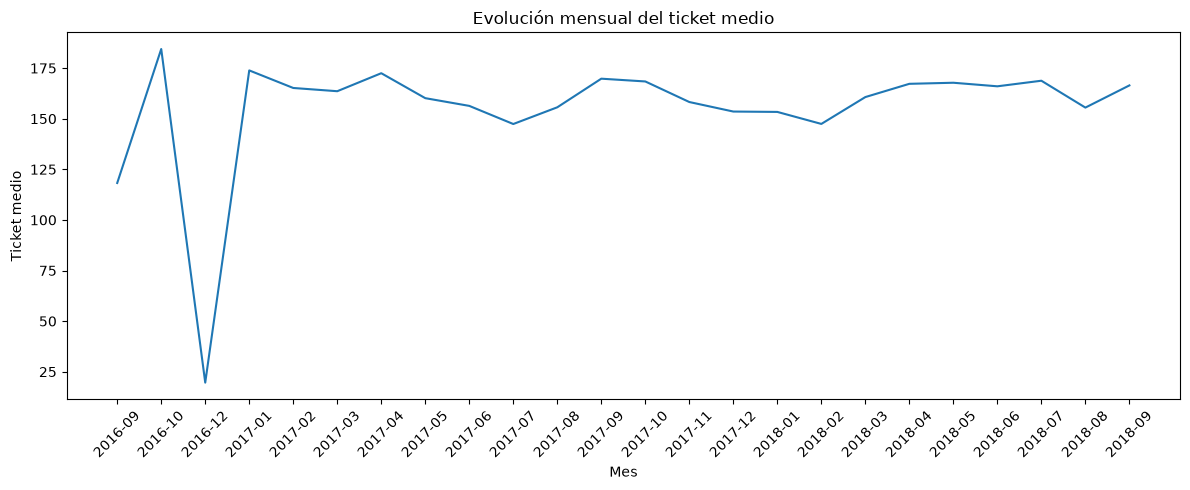

In [26]:
plt.figure(figsize=(12, 5))

plt.plot(
    evolucion_mensual["year_month"].astype(str),
    evolucion_mensual["ticket_medio"]
)

plt.title("Evolución mensual del ticket medio")
plt.xlabel("Mes")
plt.ylabel("Ticket medio")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

El ticket_medio presenta una variabilidad moderada durante la mayor parte del periodo, situándose aproximadamente entre 145 y 170 la mayoría de los meses. El incremento de ventas y pedidos no parece venir de un aumento equivalente del ticket medio, sino principalmente de un aumento del número de pedidos.

In [27]:
# Debemos comprobar si tenemos años completos para comparar

evolucion_mensual.groupby(evolucion_mensual["year_month"].dt.year)["year_month"].agg(["min", "max", "count"])

,min,max,count
year_month,,,
2016,2016-09,2016-12,3
2017,2017-01,2017-12,12
2018,2018-01,2018-09,9


Vemos que 2017 es el único año completo. 2018 solo tiene datos de enero a septiembre, y 2016 tiene únicamente tres meses. Además, no podemos comparar el mes de septiembre de 2018 ya que sabemos que solo tiene un pedido. Por tanto, para comparar la evolución interanual de forma rigurosa, se compara el periodo de enero-agosto de 2017 frente a enero-agosto de 2018.

In [36]:
# Visualizo los datos por medio de tablas dinámicas

# Primero filtro los periodos que vamos a comparar

comparacion = evolucion_mensual[
    (evolucion_mensual["year_month"].dt.year.isin([2017,2018])) &
    (evolucion_mensual["year_month"].dt.month <= 8)
].copy()

In [37]:
comparacion["month"] = comparacion["year_month"].dt.month
comparacion["year"] = comparacion["year_month"].dt.year

In [38]:
# Ahora se crea el pivot de pedidos

comparacion_pedidos = comparacion.pivot(
    index="month",
    columns="year",
    values="pedidos"
)

comparacion_pedidos

year,2017,2018
month,,
1,789,7220
2,1733,6694
3,2641,7188
4,2391,6934
5,3660,6853
6,3217,6160
7,3969,6273
8,4293,6452


In [39]:
# Variación porcentual de pedidos

comparacion_pedidos["variacion_%"] = (
    (comparacion_pedidos[2018] - comparacion_pedidos[2017])
    / comparacion_pedidos[2017]
) * 100

comparacion_pedidos

year,2017,2018,variacion_%
month,,,
1,789,7220,815.08
2,1733,6694,286.27
3,2641,7188,172.17
4,2391,6934,190.00
5,3660,6853,87.24
6,3217,6160,91.48
7,3969,6273,58.05
8,4293,6452,50.29


Se puede observar que todos los meses se han producido aumento en los pedidos, siendo especialmente fuerte el aumento al incio del año y moderandose a partir de mayo. El incremento del mes de enero no se puede valorar de la misma forma al resto de meses ya que inicio con una cantidad de pedidos bastante inferior a los demás. Para que la comparación sea mas representativa, se mide el crecimiento del periodo completo.

In [44]:
# Crecimiento del periodo completo

pedidos_2017 = comparacion_pedidos.loc[1:8, 2017].sum()
pedidos_2018 = comparacion_pedidos.loc[1:8, 2018].sum()

variacion_pedidos = ((pedidos_2018 - pedidos_2017) / pedidos_2017) *100

pedidos_2017, pedidos_2018, variacion_pedidos

(np.int64(22693), np.int64(53774), np.float64(136.96294011369145))

Ese resultado significa que entre enero y agosto de 2017 y enero y agosto de 2018, el número de pedidos aumentó un 136,96 %. Es decir, en 2018 se realizaron aproximadamente 2,37 veces más pedidos que en el mismo periodo de 2017.

In [41]:
# Ahora creo el pivot de ventas

comparacion_ventas = comparacion.pivot(
    index="month",
    columns="year",
    values="ventas"
)

comparacion_ventas

year,2017,2018
month,,
1,"137,188.49","1,107,301.89"
2,"286,280.62","986,908.96"
3,"432,048.59","1,155,126.82"
4,"412,422.24","1,159,698.04"
5,"586,190.95","1,149,781.82"
6,"502,963.04","1,022,677.11"
7,"584,971.62","1,058,728.03"
8,"668,204.60","1,003,308.47"


In [42]:
# Variación porcentual de ventas

comparacion_ventas["variacion_%"] = (
    (comparacion_ventas[2018] - comparacion_ventas[2017])
    / comparacion_ventas[2017]
) * 100

comparacion_ventas

year,2017,2018,variacion_%
month,,,
1,"137,188.49","1,107,301.89",707.14
2,"286,280.62","986,908.96",244.73
3,"432,048.59","1,155,126.82",167.36
4,"412,422.24","1,159,698.04",181.19
5,"586,190.95","1,149,781.82",96.14
6,"502,963.04","1,022,677.11",103.33
7,"584,971.62","1,058,728.03",80.99
8,"668,204.60","1,003,308.47",50.15


In [43]:
# Crecimiento del periodo completo

ventas_2017 = comparacion_ventas.loc[1:8, 2017].sum()
ventas_2018 = comparacion_ventas.loc[1:8, 2018].sum()

variacion_ventas = ((ventas_2018 - ventas_2017) / ventas_2017) *100

ventas_2017, ventas_2018, variacion_ventas

(np.float64(3610270.15), np.float64(8643531.14), np.float64(139.4150792289048))

En el caso de las ventas, vemos un comportamiento bastante similar al de pedidos, con una variación de 139,41%. Esto respalda la hipótesis de que el crecimiento d eventas se debe principalmente al aumento del volumen de pedidos y no a un aumento en el ticket medio.

In [45]:
# Comprobamos la variación del ticket medio real de cada año

ticket_2017 = (
    comparacion.loc[comparacion["year"] == 2017, "ventas"].sum()
    / comparacion.loc[comparacion["year"] == 2017, "pedidos"].sum()
)

ticket_2018 = (
    comparacion.loc[comparacion["year"] == 2018, "ventas"].sum()
    / comparacion.loc[comparacion["year"] == 2018, "pedidos"].sum()
)

ticket_2017, ticket_2018

(np.float64(159.0917970299211), np.float64(160.73811023914905))

Conclusión

El crecimiento de las ventas entre enero-agosto de 2017 y el mismo periodo de 2018 no parece estar impulsado por un aumento del ticket medio. El ticket prácticamente se mantiene estable, con un incremento de apenas 1,03 %. En cambio, los pedidos aumentan un 136,96 % y las ventas un 139,42 %.
Por tanto, podemos concluir que el crecimiento de las ventas está principalmente asociado al fuerte incremento del volumen de pedidos, mientras que el valor medio de cada pedido se mantiene prácticamente estable.

2. ¿Que categorías generan mayor volumen de ventas y pedidos?

In [50]:
# Se crea la variable de importe de ventas ya que se ve la necesidad de seguir usándola, así que se crea dentro del df principal:

df_ventas["sales_amount"] = (df_ventas["price"] + df_ventas["freight_value"])

In [54]:
# Se agrupa por categorías el número de pedidos, las ventas y el ticket medio

# Agrupación ventas por categpría de producto

ventas_categoria = (
    df_ventas
    .groupby("product_category_name_english").agg(
        pedidos=("order_id", "nunique"),
        ventas=("sales_amount", "sum"))
)

ventas_categoria["ticket_medio"] = (ventas_categoria["ventas"] / ventas_categoria["pedidos"])

ventas_categoria["porcentaje_ventas"] = (ventas_categoria["ventas"] / ventas_categoria["ventas"].sum()) *100

ventas_categoria = ventas_categoria.sort_values("ventas", ascending=False)

ventas_categoria.head(10)

,pedidos,ventas,ticket_medio,porcentaje_ventas
product_category_name_english,,,,
health_beauty,8836,"1,441,248.07",163.11,9.22
watches_gifts,5624,"1,305,541.61",232.14,8.35
bed_bath_table,9417,"1,241,681.72",131.86,7.94
sports_leisure,7720,"1,156,656.48",149.83,7.40
computers_accessories,6689,"1,059,272.40",158.36,6.77
furniture_decor,6449,"902,511.79",139.95,5.77
housewares,5884,"778,397.77",132.29,4.98
cool_stuff,3632,"719,329.95",198.05,4.60
auto,3897,"685,384.32",175.87,4.38


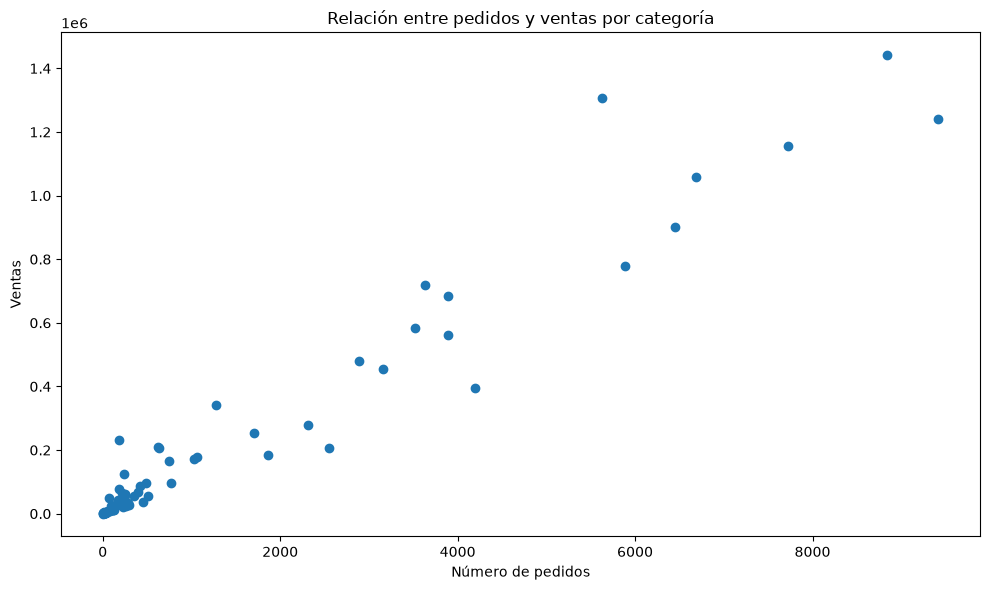

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(ventas_categoria["pedidos"], ventas_categoria["ventas"])

plt.title("Relación entre pedidos y ventas por categoría")
plt.xlabel("Número de pedidos")
plt.ylabel("Ventas")

plt.tight_layout()
plt.show()

Existe una relación positiva: en general, las categorías con más pedidos generan más ventas. Hay una mayor concentración de categorías en la zona de menor volumen de pedidos y ventas.

In [56]:
# Cuantificar la correlación

correlacion = ventas_categoria["pedidos"].corr(ventas_categoria["ventas"])
correlacion

np.float64(0.9696486564482402)

Se confirma la relación positiva fuerta entre las categorías, en donde las categorías con mayor número de pedidos tienden a generar mayor número de ventas.

In [57]:
# Categorías por ticket medio

ventas_categoria.sort_values("ticket_medio", ascending=False).head(10)

,pedidos,ventas,ticket_medio,porcentaje_ventas
product_category_name_english,,,,
computers,181,"232,799.43","1,286.18",1.49
small_appliances_home_oven_and_coffee,75,"50,193.57",669.25,0.32
home_appliances_2,234,"123,917.92",529.56,0.79
agro_industry_and_commerce,182,"78,374.07",430.63,0.50
musical_instruments,628,"210,137.37",334.61,1.34
small_appliances,630,"206,668.83",328.05,1.32
portable_kitchen_and_food_preparers,14,"4,278.29",305.59,0.03
fixed_telephony,217,"64,220.81",295.95,0.41
office_furniture,1273,"342,532.65",269.08,2.19


In [58]:
ventas_categoria.sort_values("ticket_medio", ascending=True).head(10)

,pedidos,ventas,ticket_medio,porcentaje_ventas
product_category_name_english,,,,
home_comfort_2,24,"1,170.58",48.77,0.01
flowers,29,"1,598.91",55.13,0.01
diapers_and_hygiene,27,"2,141.27",79.31,0.01
cds_dvds_musicals,12,954.99,79.58,0.01
electronics,2550,"206,825.06",81.11,1.32
food,450,"36,664.44",81.48,0.23
fashion_childrens_clothes,8,665.36,83.17,0.00
food_drink,227,"19,687.47",86.73,0.13
fashio_female_clothing,39,"3,425.39",87.83,0.02


Se identifica una gran heterogeneidad en el ticket medio, ya que el el importe no implica necesariamente una gran participación en ventas. Las categorías con mayor facturación son principalmente aquellas que combinan un número elevado de pedidos con un ticket medio moderado. Esto refuerza la idea de que el volumen de pedidos es el factor que más se relaciona con la facturación entre categorías.

In [60]:
# Categorías que concentran las ventas

ventas_categoria["porcentaje_acumulado"] = ventas_categoria["porcentaje_ventas"].cumsum()
ventas_categoria.head(20)

,pedidos,ventas,ticket_medio,porcentaje_ventas,porcentaje_acumulado
product_category_name_english,,,,,
health_beauty,8836,"1,441,248.07",163.11,9.22,9.22
watches_gifts,5624,"1,305,541.61",232.14,8.35,17.57
bed_bath_table,9417,"1,241,681.72",131.86,7.94,25.51
sports_leisure,7720,"1,156,656.48",149.83,7.40,32.91
computers_accessories,6689,"1,059,272.40",158.36,6.77,39.68
furniture_decor,6449,"902,511.79",139.95,5.77,45.45
housewares,5884,"778,397.77",132.29,4.98,50.43
cool_stuff,3632,"719,329.95",198.05,4.60,55.03
auto,3897,"685,384.32",175.87,4.38,59.41


Las ventas presentan una concentración significativa: las 17 categorías con mayor facturación acumulan el 80,83 % de las ventas totales. Esto indica que una parte mayoritaria de los ingresos procede de un grupo relativamente reducido de categorías, aunque no se observa una concentración extrema en las primeras posiciones, ya que son necesarias 17 categorías para superar el umbral del 80 %.

3. ¿Qué estados y ciudades concentran la mayor parte de las ventas?

In [80]:
# Distribución por estado

ventas_estado = df_ventas.groupby("customer_state").agg(
    pedidos=("order_id", "nunique"),
    ventas= ("sales_amount", "sum")
)

ventas_estado.head()

,pedidos,ventas
customer_state,,
AC,81,"19,669.70"
AL,411,"96,229.40"
AM,147,"27,835.73"
AP,68,"16,262.80"
BA,3358,"611,506.67"


In [81]:
# Se añade ticket medio

ventas_estado["ticket_medio"] = (ventas_estado["ventas"] / ventas_estado["pedidos"])

ventas_estado = ventas_estado.sort_values("ventas", ascending=False)

ventas_estado.head(10)

,pedidos,ventas,ticket_medio
customer_state,,,
SP,41375,"5,921,678.12",143.12
RJ,12762,"2,129,681.98",166.88
MG,11544,"1,856,161.49",160.79
RS,5432,"885,826.76",163.08
PR,4998,"800,935.44",160.25
BA,3358,"611,506.67",182.10
SC,3612,"610,213.60",168.94
DF,2125,"353,229.44",166.23
GO,2007,"347,706.93",173.25


In [82]:
# Se añade porcentaje

ventas_estado["porcentaje_ventas"] = (ventas_estado["ventas"] / ventas_estado["ventas"].sum()) * 100

ventas_estado.head(10)

,pedidos,ventas,ticket_medio,porcentaje_ventas
customer_state,,,,
SP,41375,"5,921,678.12",143.12,37.38
RJ,12762,"2,129,681.98",166.88,13.44
MG,11544,"1,856,161.49",160.79,11.72
RS,5432,"885,826.76",163.08,5.59
PR,4998,"800,935.44",160.25,5.06
BA,3358,"611,506.67",182.10,3.86
SC,3612,"610,213.60",168.94,3.85
DF,2125,"353,229.44",166.23,2.23
GO,2007,"347,706.93",173.25,2.19


In [83]:
# Concentración de ventas por estado

ventas_estado["porcentaje_acumulado"] = (ventas_estado["porcentaje_ventas"].cumsum())

ventas_estado

,pedidos,ventas,ticket_medio,porcentaje_ventas,porcentaje_acumulado
customer_state,,,,,
SP,41375,"5,921,678.12",143.12,37.38,37.38
RJ,12762,"2,129,681.98",166.88,13.44,50.82
MG,11544,"1,856,161.49",160.79,11.72,62.53
RS,5432,"885,826.76",163.08,5.59,68.12
PR,4998,"800,935.44",160.25,5.06,73.18
BA,3358,"611,506.67",182.10,3.86,77.04
SC,3612,"610,213.60",168.94,3.85,80.89
DF,2125,"353,229.44",166.23,2.23,83.12
GO,2007,"347,706.93",173.25,2.19,85.32


SP por sí solo representa el 37,38 % de las ventas. Los 3 primeros estados acumulan el 62,53 %. Los 7 primeros estados alcanzan el 80,89 %. Por tanto, las ventas están más concentradas geográficamente por estado que por vendedor.

In [84]:
# Análisis por ciudad

ventas_ciudad = (df_ventas.groupby("customer_city").agg(
        pedidos=("order_id", "nunique"),
        ventas=("sales_amount", "sum"))
)

ventas_ciudad.head()

,pedidos,ventas
customer_city,,
abadia dos dourados,3,413.50
abadiania,1,"1,025.52"
abaete,12,"1,946.81"
abaetetuba,11,"4,672.27"
abaiara,2,332.15


In [ ]:
# Ticket medio por ciudad

ventas_ciudad["ticket_medio"] = (ventas_ciudad["ventas"] / ventas_ciudad["pedidos"])

ventas_ciudad = ventas_ciudad.sort_values("ventas", ascending=False)

ventas_ciudad.head(10)

,pedidos,ventas,ticket_medio
customer_city,,,
sao paulo,15402,"2,170,227.12",140.91
rio de janeiro,6834,"1,154,234.02",168.90
belo horizonte,2750,"416,733.39",151.54
brasilia,2116,"352,305.14",166.50
curitiba,1510,"244,739.87",162.08
porto alegre,1372,"224,064.09",163.31
salvador,1238,"216,772.40",175.10
campinas,1429,"212,541.70",148.73
guarulhos,1178,"163,575.82",138.86


In [86]:
# Porcentaje por ciudad

ventas_ciudad["porcentaje_ventas"] = (ventas_ciudad["ventas"] / ventas_ciudad["ventas"].sum()) * 100

ventas_ciudad.head(10)

,pedidos,ventas,ticket_medio,porcentaje_ventas
customer_city,,,,
sao paulo,15402,"2,170,227.12",140.91,13.70
rio de janeiro,6834,"1,154,234.02",168.90,7.29
belo horizonte,2750,"416,733.39",151.54,2.63
brasilia,2116,"352,305.14",166.50,2.22
curitiba,1510,"244,739.87",162.08,1.54
porto alegre,1372,"224,064.09",163.31,1.41
salvador,1238,"216,772.40",175.10,1.37
campinas,1429,"212,541.70",148.73,1.34
guarulhos,1178,"163,575.82",138.86,1.03


In [87]:
# Porcentaje acumulado

ventas_ciudad["porcentaje_acumulado"] = (ventas_ciudad["porcentaje_ventas"].cumsum())

In [88]:
# Ciudades que cubren el 80% de las ventas

ciudades_80 = (ventas_ciudad["porcentaje_acumulado"] < 80).sum() + 1

ciudades_80

np.int64(386)

La concentración es muy alta a nivel estatal pero mucho mas dispersa cuando se baja al nivel de ciudad.

In [ ]:
# Coorelación de ventas a nivel estatal

ventas_estado["pedidos"].corr(ventas_estado["ventas"])

np.float64(0.9985068666343534)

In [ ]:
# Correlación de ventas a nivel ciudad

ventas_ciudad["pedidos"].corr(ventas_ciudad["ventas"])

np.float64(0.9966131942287494)

Las ventas presentan una alta concentración a nivel estatal: los 7 estados con mayor facturación acumulan el 80,89 % de las ventas, destacando São Paulo con un 37,38 %. Sin embargo, al analizar las ciudades, la distribución es mucho más dispersa, siendo necesarias 386 ciudades para alcanzar el 80 % de las ventas.
La facturación está fuertemente relacionada con el volumen de pedidos: la correlación entre pedidos y ventas es de 0,9985 en los estados y 0,9966 en las ciudades. Esto indica que las diferencias de ventas entre zonas geográficas se explican principalmente por el número de pedidos, mientras que el ticket medio tiene una influencia secundaria.

4. ¿Cómo se distribuyen las ventas entre los vendedores y existe una concentración relevante en un grupo reducido de ellos?

In [61]:
# Cantidad de vendedores por ventas

ventas_vendedor = df_ventas.groupby("seller_id").agg(
    pedidos= ("order_id", "nunique"),
    ventas= ("sales_amount", "sum")
)

ventas_vendedor.head()

,pedidos,ventas
seller_id,,
0015a82c2db000af6aaaf3ae2ecb0532,3,"2,748.06"
001cca7ae9ae17fb1caed9dfb1094831,200,"33,934.17"
001e6ad469a905060d959994f1b41e4f,1,267.94
002100f778ceb8431b7a1020ff7ab48f,51,"2,028.16"
003554e2dce176b5555353e4f3555ac8,1,139.38


In [62]:
# Se añade el ticket medio a la tabla

ventas_vendedor["ticket_medio"] = ventas_vendedor["ventas"] / ventas_vendedor["pedidos"]

ventas_vendedor.head()

,pedidos,ventas,ticket_medio
seller_id,,,
0015a82c2db000af6aaaf3ae2ecb0532,3,"2,748.06",916.02
001cca7ae9ae17fb1caed9dfb1094831,200,"33,934.17",169.67
001e6ad469a905060d959994f1b41e4f,1,267.94,267.94
002100f778ceb8431b7a1020ff7ab48f,51,"2,028.16",39.77
003554e2dce176b5555353e4f3555ac8,1,139.38,139.38


In [65]:
ventas_vendedor = ventas_vendedor.sort_values("ventas", ascending=False)

ventas_vendedor.head(10)

,pedidos,ventas,ticket_medio
seller_id,,,
4869f7a5dfa277a7dca6462dcf3b52b2,1132,"249,640.70",220.53
7c67e1448b00f6e969d365cea6b010ab,982,"239,536.44",243.93
53243585a1d6dc2643021fd1853d8905,358,"235,856.68",658.82
4a3ca9315b744ce9f8e9374361493884,1806,"235,539.96",130.42
fa1c13f2614d7b5c4749cbc52fecda94,585,"204,084.73",348.86
da8622b14eb17ae2831f4ac5b9dab84a,1314,"185,192.32",140.94
7e93a43ef30c4f03f38b393420bc753a,336,"182,754.05",543.91
1025f0e2d44d7041d6cf58b6550e0bfa,915,"172,860.69",188.92
7a67c85e85bb2ce8582c35f2203ad736,1160,"162,648.38",140.21


En la tabla se puede ver una diferencia entre volumen y valor por pedido. No necesariamente tener mas pedidos implica tener mayor facturación.

In [67]:
# se añade el porcentaje de ventas

ventas_vendedor["porcentaje_ventas"] = (ventas_vendedor["ventas"] / ventas_vendedor["ventas"].sum()) *100 

ventas_vendedor.head(10)

,pedidos,ventas,ticket_medio,porcentaje_ventas
seller_id,,,,
4869f7a5dfa277a7dca6462dcf3b52b2,1132,"249,640.70",220.53,1.58
7c67e1448b00f6e969d365cea6b010ab,982,"239,536.44",243.93,1.51
53243585a1d6dc2643021fd1853d8905,358,"235,856.68",658.82,1.49
4a3ca9315b744ce9f8e9374361493884,1806,"235,539.96",130.42,1.49
fa1c13f2614d7b5c4749cbc52fecda94,585,"204,084.73",348.86,1.29
da8622b14eb17ae2831f4ac5b9dab84a,1314,"185,192.32",140.94,1.17
7e93a43ef30c4f03f38b393420bc753a,336,"182,754.05",543.91,1.15
1025f0e2d44d7041d6cf58b6550e0bfa,915,"172,860.69",188.92,1.09
7a67c85e85bb2ce8582c35f2203ad736,1160,"162,648.38",140.21,1.03


No se observan vendedores con un peso individual dominante. El primer vendedor representa solo el 1,58% de las ventas y los 10 primeros están todos alrededor de 1 - 1,5%.

In [70]:
# Se añade la concentración acumulada

ventas_vendedor["porcentaje_acumulado"] = (ventas_vendedor["porcentaje_ventas"].cumsum())

ventas_vendedor.head(20)

,pedidos,ventas,ticket_medio,porcentaje_ventas,porcentaje_acumulado
seller_id,,,,,
4869f7a5dfa277a7dca6462dcf3b52b2,1132,"249,640.70",220.53,1.58,1.58
7c67e1448b00f6e969d365cea6b010ab,982,"239,536.44",243.93,1.51,3.09
53243585a1d6dc2643021fd1853d8905,358,"235,856.68",658.82,1.49,4.58
4a3ca9315b744ce9f8e9374361493884,1806,"235,539.96",130.42,1.49,6.06
fa1c13f2614d7b5c4749cbc52fecda94,585,"204,084.73",348.86,1.29,7.35
da8622b14eb17ae2831f4ac5b9dab84a,1314,"185,192.32",140.94,1.17,8.52
7e93a43ef30c4f03f38b393420bc753a,336,"182,754.05",543.91,1.15,9.67
1025f0e2d44d7041d6cf58b6550e0bfa,915,"172,860.69",188.92,1.09,10.76
7a67c85e85bb2ce8582c35f2203ad736,1160,"162,648.38",140.21,1.03,11.79


In [76]:
# Vendedores que hacen falta para alcanzar un 80%

vendedores_80 = (ventas_vendedor["porcentaje_acumulado"] < 80).sum() +1

vendedores_80

np.int64(562)

Se necesitan 562 vendedores para alcanzar aproximadamente el 80 % de las ventas. Por tanto, no existe una concentración fuerte de ventas en unos pocos vendedores. La facturación está bastante distribuida.

In [77]:
# Proporción del total de vendedores que representan esos 561

proporcion_vendedores_80 = (vendedores_80 / len(ventas_vendedor)) *100

proporcion_vendedores_80

np.float64(18.15831987075929)

El 80 % de las ventas procede aproximadamente del 18,16 % de los vendedores.

In [78]:
# Correlación pedidos y ventas de los vendedores

ventas_vendedor["pedidos"].corr(ventas_vendedor["ventas"])

np.float64(0.8342486527123577)

0,83 indica una correlación lineal positiva fuerte entre el número de pedidos y las ventas de los vendedores. Por tanto, en los vendedores el número de pedidos explica buena parte de las diferencias de facturación, pero el ticket medio también tiene un papel relevante.

In [79]:
# Distribución del ticket medio de los vendedores

ventas_vendedor["ticket_medio"].describe()

count   3,095.00
mean      221.39
std       358.62
min        12.22
25%        79.77
50%       128.82
75%       219.86
max     6,922.21
Name: ticket_medio, dtype: float64

La diferencia entre media (221,39 €) y mediana (128,82 €), junto con una desviación estándar bastante superior a la media, indica una distribución sesgada hacia la derecha: la mayoría de vendedores tienen tickets relativamente bajos, mientras que un grupo pequeño presenta tickets mucho más elevados. Además, el máximo de 6.922,21 € es muy superior al tercer cuartil, por lo que hay valores extremos que elevan la media.

5. ¿Qué métodos de pago utilizan los clientes y cómo se relacionan con las ventas?

In [92]:
# Distribución de métodos de pago

metodos_pago = (order_payments.groupby("payment_type").agg(
        registros=("order_id", "count"),
        pedidos=("order_id", "nunique")
    )
    .sort_values("pedidos", ascending=False)
)

metodos_pago

,registros,pedidos
payment_type,,
credit_card,76795,76505
boleto,19784,19784
voucher,5775,3866
debit_card,1529,1528
not_defined,3,3


In [93]:
# Porcentaje de pedidos por método

metodos_pago["porcentaje_pedidos"] = (metodos_pago["pedidos"] / metodos_pago["pedidos"].sum()) * 100

metodos_pago

,registros,pedidos,porcentaje_pedidos
payment_type,,,
credit_card,76795,76505,75.24
boleto,19784,19784,19.46
voucher,5775,3866,3.80
debit_card,1529,1528,1.50
not_defined,3,3,0.00


Los dos métodos principales, credit card + boleto, concentran 94,70 % de los pedidos. Por tanto, existe una fuerte concentración en las preferencias de pago.

In [95]:
# Pedidos con más de un método de pago

pagos_por_pedido = (order_payments.groupby("order_id")["payment_type"].nunique())

pagos_por_pedido.value_counts().sort_index()


payment_type
1    97194
2     2246
Name: count, dtype: int64

97.194 pedidos (97,7 % aprox.) utilizan un único método de pago. 2.246 pedidos utilizan dos métodos diferentes.

In [97]:
# Importe pagado por método

valor_pago = (order_payments.groupby("payment_type").agg(
        pagos=("payment_value", "sum"),
        pedidos=("order_id", "nunique")
    ).sort_values("pagos", ascending=False)
)

valor_pago

,pagos,pedidos
payment_type,,
credit_card,"12,542,084.19",76505
boleto,"2,869,361.27",19784
voucher,"379,436.87",3866
debit_card,"217,989.79",1528
not_defined,0.00,3


In [98]:
# Importe medio pagado por cada método

valor_pago["importe_medio"] = valor_pago["pagos"] / valor_pago["pedidos"]

valor_pago

,pagos,pedidos,importe_medio
payment_type,,,
credit_card,"12,542,084.19",76505,163.94
boleto,"2,869,361.27",19784,145.03
voucher,"379,436.87",3866,98.15
debit_card,"217,989.79",1528,142.66
not_defined,0.00,3,0.00


La tarjeta de crédito es el método dominante, tanto en frecuencia como en valor económico. Además, presenta el importe medio más elevado entre los métodos relevantes, con 163,94 €. El voucher tiene un comportamiento diferente, ya que aunque aparece en 3,80 % de los pedidos, su importe medio es bastante menor (98,15 €).

In [99]:
# Correlación entre el número de pedidos y el importe total de cada método

valor_pago["pedidos"].corr(valor_pago["pagos"])

np.float64(0.9995100596730289)

Correlación alta pero al tener un número de métodos analizado tan reducido, no es un resultado concluyente por si solo. En conjunto, los resultados muestran una clara preferencia por la tarjeta de crédito, tanto por frecuencia de uso como por valor económico.

### Bloque 2. Comportamiento de los clientes

6. ¿Cómo se distribuyen los clientes y qué características presentan?

In [100]:
# Distribución de clientes por estado

clientes_estado = (df_ventas.groupby("customer_state").agg(
        clientes=("customer_unique_id", "nunique")
    ).sort_values("clientes", ascending=False)
)

clientes_estado.head(10)

,clientes
customer_state,
SP,39981
RJ,12303
MG,11178
RS,5249
PR,4840
SC,3513
BA,3257
DF,2062
ES,1956


In [101]:
# Concentración de clientes por estado

clientes_estado["porcentaje_clientes"] = (clientes_estado["clientes"] / clientes_estado["clientes"].sum()) * 100

clientes_estado.head(10)

,clientes,porcentaje_clientes
customer_state,,
SP,39981,41.88
RJ,12303,12.89
MG,11178,11.71
RS,5249,5.50
PR,4840,5.07
SC,3513,3.68
BA,3257,3.41
DF,2062,2.16
ES,1956,2.05


In [102]:
# Tabla con el porcentaje de clientes

comparacion_estado = clientes_estado[["porcentaje_clientes"]].copy()

comparacion_estado["porcentaje_ventas"] = ventas_estado["porcentaje_ventas"]

In [104]:
comparacion_estado["diferencia"] = (comparacion_estado["porcentaje_ventas"] - comparacion_estado["porcentaje_clientes"])

comparacion_estado.sort_values("diferencia", ascending=False)

,porcentaje_clientes,porcentaje_ventas,diferencia
customer_state,,,
RJ,12.89,13.44,0.55
BA,3.41,3.86,0.45
PA,0.99,1.37,0.38
CE,1.37,1.74,0.37
PE,1.68,2.03,0.35
PB,0.54,0.89,0.35
MT,0.91,1.18,0.26
MA,0.75,0.95,0.20
AL,0.42,0.61,0.19


In [105]:
# Correlación 

comparacion_estado["porcentaje_clientes"].corr(comparacion_estado["porcentaje_ventas"])

np.float64(0.998499858545485)

0,9985 indica una relación lineal prácticamente perfecta entre el peso de los clientes y el peso de las ventas por estado. Lo que significa que, en términos generales, los estados que concentran más clientes también concentran más ventas.

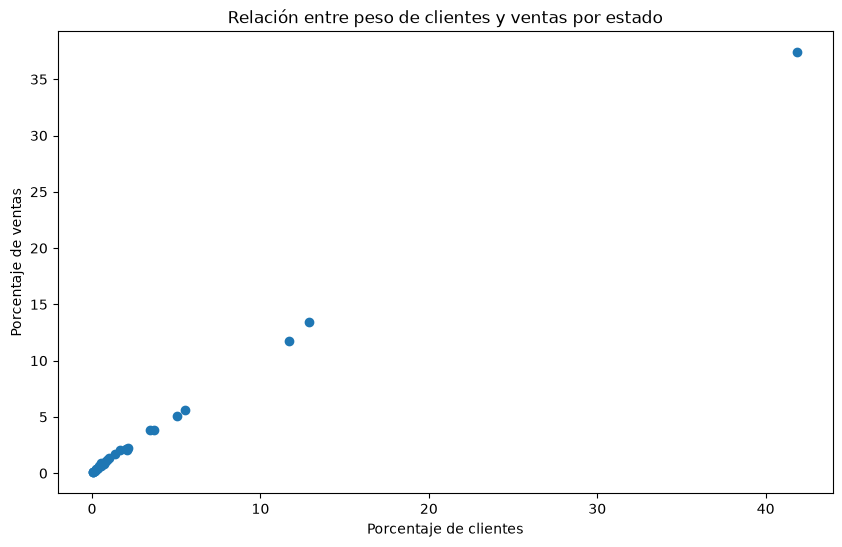

In [106]:
# Gráfico de dispersión entre las dos variables

plt.scatter(
    comparacion_estado["porcentaje_clientes"],
    comparacion_estado["porcentaje_ventas"]
)

plt.xlabel("Porcentaje de clientes")
plt.ylabel("Porcentaje de ventas")
plt.title("Relación entre peso de clientes y ventas por estado")

plt.show()

Existe una tendencia lineal positiva muy clara, coherente con la correlación de 0,9985. La mayoría de los estados están concentrados en valores bajos de porcentaje de clientes y ventas. Hay dos estados con una concentración bastante mayor, entre el 10 % y el 20 %.
SP es el punto claramente atípico, muy alejado del resto por su enorme peso en clientes y ventas.

In [108]:
# Distribución de clientes según su recurrencia

pedidos_cliente = df_ventas.groupby("customer_unique_id").agg(
    pedidos= ("order_id", "nunique")
)

pedidos_cliente.head(10)

,pedidos
customer_unique_id,
0000366f3b9a7992bf8c76cfdf3221e2,1
0000b849f77a49e4a4ce2b2a4ca5be3f,1
0000f46a3911fa3c0805444483337064,1
0000f6ccb0745a6a4b88665a16c9f078,1
0004aac84e0df4da2b147fca70cf8255,1
0004bd2a26a76fe21f786e4fbd80607f,1
00050ab1314c0e55a6ca13cf7181fecf,1
00053a61a98854899e70ed204dd4bafe,1
0005e1862207bf6ccc02e4228effd9a0,1


In [109]:
pedidos_cliente["pedidos"].value_counts().sort_index()

pedidos
1     92507
2      2673
3       192
4        29
5         9
6         5
7         3
9         1
16        1
Name: count, dtype: int64

In [111]:
# Porcentaje de clientes recurrentes

clientes_recurrentes = (pedidos_cliente["pedidos"] >1).sum()

porcentaje_recurrentes = (clientes_recurrentes / len(pedidos_cliente)) *100

porcentaje_recurrentes

np.float64(3.0528191154894153)

In [112]:
# Porcentaje de clientes que solo realizaron un pedido

porcentaje_un_pedido = ((pedidos_cliente["pedidos"] == 1).sum() / len(pedidos_cliente)) * 100

porcentaje_un_pedido

np.float64(96.94718088451059)

96,95 % de los clientes realizaron un único pedido. Solo 3,05 % son clientes recurrentes.
Por tanto, la recurrencia es muy baja en el conjunto analizado. Esto es especialmente relevante para el negocio, porque el volumen de clientes es enorme, pero la gran mayoría no vuelve a comprar.

In [113]:
# Distribución del número de pedidos en clientes recurrentes

pedidos_cliente[pedidos_cliente["pedidos"] >1]["pedidos"].describe()

count   2,913.00
mean        2.11
std         0.51
min         2.00
25%         2.00
50%         2.00
75%         2.00
max        16.00
Name: pedidos, dtype: float64

Entre los clientes recurrentes, la mediana es 2 pedidos y el 75 % también está en 2. Es decir, la recurrencia existe, pero normalmente consiste en una segunda compra puntual, no en una relación de compra frecuente. El máximo de 16 pedidos es claramente un caso extremo.

7. ¿Qué clientes o segmentos generan mayor valor para el negocio?

In [117]:
# Valor generado por el cliente

valor_cliente = (df_ventas.groupby("customer_unique_id").agg(
        pedidos=("order_id", "nunique"),
        ventas=("sales_amount", "sum")
    ).sort_values("ventas", ascending=False)
)

valor_cliente.head(10)

,pedidos,ventas
customer_unique_id,,
0a0a92112bd4c708ca5fde585afaa872,1,"13,664.08"
da122df9eeddfedc1dc1f5349a1a690c,2,"7,571.63"
763c8b1c9c68a0229c42c9fc6f662b93,1,"7,274.88"
dc4802a71eae9be1dd28f5d788ceb526,1,"6,929.31"
459bef486812aa25204be022145caa62,1,"6,922.21"
ff4159b92c40ebe40454e3e6a7c35ed6,1,"6,726.66"
4007669dec559734d6f53e029e360987,1,"6,081.54"
5d0a2980b292d049061542014e8960bf,1,"4,809.44"
eebb5dda148d3893cdaf5b5ca3040ccb,1,"4,764.34"


In [118]:
# Ticket medio por cliente

valor_cliente["ticket_medio"] = (valor_cliente["ventas"] / valor_cliente["pedidos"])

valor_cliente.head(10)

,pedidos,ventas,ticket_medio
customer_unique_id,,,
0a0a92112bd4c708ca5fde585afaa872,1,"13,664.08","13,664.08"
da122df9eeddfedc1dc1f5349a1a690c,2,"7,571.63","3,785.82"
763c8b1c9c68a0229c42c9fc6f662b93,1,"7,274.88","7,274.88"
dc4802a71eae9be1dd28f5d788ceb526,1,"6,929.31","6,929.31"
459bef486812aa25204be022145caa62,1,"6,922.21","6,922.21"
ff4159b92c40ebe40454e3e6a7c35ed6,1,"6,726.66","6,726.66"
4007669dec559734d6f53e029e360987,1,"6,081.54","6,081.54"
5d0a2980b292d049061542014e8960bf,1,"4,809.44","4,809.44"
eebb5dda148d3893cdaf5b5ca3040ccb,1,"4,764.34","4,764.34"


In [119]:
valor_cliente[["ventas", "ticket_medio"]].describe()

,ventas,ticket_medio
count,"95,420.00","95,420.00"
mean,166.04,161.04
std,228.32,221.19
min,9.59,9.59
25%,63.10,62.41
50%,107.94,105.77
75%,183.22,177.12
max,"13,664.08","13,664.08"


La diferencia entre media y mediana es importante, la media está bastante por encima de la mediana. Esto indica una distribución sesgada a la derecha, provocada por clientes con valores excepcionalmente elevados. Además, el máximo de 13.664,08 € es enorme respecto a la mediana de 107,94 €, por lo que tenemos una clara presencia de valores extremos.

In [120]:
# Se calcula la asimetría

valor_cliente["ventas"].skew()

np.float64(9.088563769442326)

Skewness = 9,09 confirma una asimetría positiva muy fuerte en las ventas por cliente. La distribución está claramente desplazada hacia la derecha por un número reducido de clientes con valores excepcionalmente altos.

In [123]:
# Concetración de ventas entre los clientes

valor_cliente["porcentaje_ventas"] = (valor_cliente["ventas"] / valor_cliente["ventas"].sum()) * 100

valor_cliente["porcentaje_acumulado"] = (valor_cliente["porcentaje_ventas"].cumsum())

valor_cliente.head(20)

,pedidos,ventas,ticket_medio,porcentaje_ventas,porcentaje_acumulado
customer_unique_id,,,,,
0a0a92112bd4c708ca5fde585afaa872,1,"13,664.08","13,664.08",0.09,0.09
da122df9eeddfedc1dc1f5349a1a690c,2,"7,571.63","3,785.82",0.05,0.13
763c8b1c9c68a0229c42c9fc6f662b93,1,"7,274.88","7,274.88",0.05,0.18
dc4802a71eae9be1dd28f5d788ceb526,1,"6,929.31","6,929.31",0.04,0.22
459bef486812aa25204be022145caa62,1,"6,922.21","6,922.21",0.04,0.27
ff4159b92c40ebe40454e3e6a7c35ed6,1,"6,726.66","6,726.66",0.04,0.31
4007669dec559734d6f53e029e360987,1,"6,081.54","6,081.54",0.04,0.35
5d0a2980b292d049061542014e8960bf,1,"4,809.44","4,809.44",0.03,0.38
eebb5dda148d3893cdaf5b5ca3040ccb,1,"4,764.34","4,764.34",0.03,0.41


In [124]:
clientes_80 = (valor_cliente["porcentaje_acumulado"] <= 80).sum() + 1

clientes_80

np.int64(46506)

In [125]:
proporcion_clientes_80 = (clientes_80 / len(valor_cliente)) * 100

proporcion_clientes_80

np.float64(48.73821001886397)

El 80 % de las ventas está generado por aproximadamente el 48,7 % de los clientes. El valor está relativamente concentrado, pero no de forma extrema. La concentración es mucho menor que la que vimos en categorías. También es bastante menor que la concentración que observamos entre vendedores.

In [126]:
# Comparación clientes recurrentes vs clientes con un solo pedido

valor_cliente["tipo_cliente"] = np.where(valor_cliente["pedidos"] == 1, "Un pedido", "Recurrente")

In [127]:
comparacion_clientes = (valor_cliente.groupby("tipo_cliente").agg(
        clientes=("ventas", "count"),
        ventas=("ventas", "sum"),
        ventas_media=("ventas", "mean"),
        ticket_medio=("ticket_medio", "mean"))
)

comparacion_clientes

,clientes,ventas,ventas_media,ticket_medio
tipo_cliente,,,,
Recurrente,2913,"904,446.25",310.49,146.85
Un pedido,92507,"14,939,106.99",161.49,161.49


En conjunto, los resultados indican que la principal oportunidad no está únicamente en captar clientes de mayor valor, sino en aumentar la conversión de clientes de primera compra hacia una segunda compra, ya que la recurrencia prácticamente duplica el valor medio generado por cliente.

### Bloque 3. Productos

8. ¿Qué características de los productos están relacionadas con su rendimiento comercial?

In [130]:
df_ventas.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id', 'price',
       'freight_value', 'customer_id', 'order_status',
       'order_purchase_timestamp', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_unique_id', 'customer_city',
       'customer_state', 'product_category_name_english', 'seller_city',
       'seller_state', 'geolocation_lat', 'geolocation_lng', 'sales_amount'],
      dtype='str')

In [129]:
df_ventas["price"].describe()

count   112,650.00
mean        120.65
std         183.63
min           0.85
25%          39.90
50%          74.99
75%         134.90
max       6,735.00
Name: price, dtype: float64

La media está bastante por encima de la mediana y la desviación estándar es elevada (183,63 €), así que tenemos una distribución asimétrica hacia la derecha, con productos de precio muy elevado.

In [131]:
# Tabla por producto

rendimiento_producto = (df_ventas.groupby("product_id").agg(
        unidades_vendidas=("order_item_id", "count"),
        ventas=("sales_amount", "sum"),
        precio=("price", "first")
    )
    .sort_values("ventas", ascending=False)
)

rendimiento_producto.head(10)

,unidades_vendidas,ventas,precio
product_id,,,
bb50f2e236e5eea0100680137654686c,195,"67,606.10",330.00
d1c427060a0f73f6b889a5c7c61f2ac4,343,"60,976.03",149.00
6cdd53843498f92890544667809f1595,156,"59,093.99",349.90
99a4788cb24856965c36a24e339b6058,488,"51,071.60",74.00
d6160fb7873f184099d9bc95e30376af,35,"50,326.18","1,300.00"
3dd2a17168ec895c781a9191c1e95ad7,274,"48,212.22",149.90
aca2eb7d00ea1a7b8ebd4e68314663af,527,"44,820.76",69.90
5f504b3a1c75b73d6151be81eb05bdc9,63,"41,725.81",610.00
25c38557cf793876c5abdd5931f922db,38,"40,311.95","1,106.99"


No se ve una relación clara entre precio y ventas, ya que aparecen productos de precio medio y bajo que venden muchas unidades, así como productos caros que generan mucha facturación con pocas unidades.

In [132]:
# Correlación precio - unidades vendidas

rendimiento_producto["precio"].corr(rendimiento_producto["unidades_vendidas"])

np.float64(-0.032395131047841356)

−0,0323 es una correlación prácticamente nula. Eso significa que, en este conjunto de productos, el precio prácticamente no está relacionado linealmente con el número de unidades vendidas.

In [ ]:
# Correlación precio - facturación

rendimiento_producto["precio"].corr(rendimiento_producto["ventas"])

np.float64(0.2797524264453379)

0,279 es una relación positiva débil. Es decir, los productos más caros tienden ligeramente a generar más facturación, pero la relación es demasiado débil como para decir que el precio sea un factor determinante de las ventas.

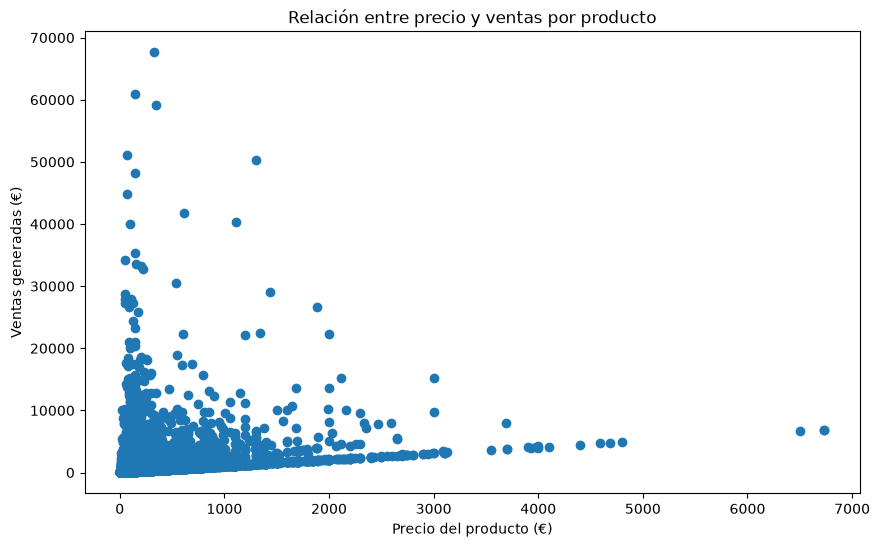

In [134]:
plt.scatter(
    rendimiento_producto["precio"],
    rendimiento_producto["ventas"]
)

plt.xlabel("Precio del producto (€)")
plt.ylabel("Ventas generadas (€)")
plt.title("Relación entre precio y ventas por producto")

plt.show()

El gráfico muestra una distribución muy concentrada en productos de precio bajo, con una gran dispersión de las ventas en ese rango. A medida que aumenta el precio, los productos son menos numerosos y sus ventas tienden a mantenerse en niveles bajos.

In [135]:
# Agrupación de productos por rangos de precios

rendimiento_producto["rango_precio"] = pd.cut(
    rendimiento_producto["precio"],
    bins=[0, 50, 100, 200, 500, 1000, float("inf")],
    labels=[
        "0-50 €",
        "50-100 €",
        "100-200 €",
        "200-500 €",
        "500-1000 €",
        "+1000 €"
    ]
)

Como parte del desarrollo del análisis se investigó y aplicó la función pd.cut() de Pandas, aprendiendo a utilizarla para segmentar una variable numérica en intervalos. Su aplicación permitió analizar de forma más sencilla la distribución de las ventas según diferentes rangos de precio.

In [136]:
rendimiento_precio = (rendimiento_producto.groupby("rango_precio", observed=False).agg(
        productos=("precio", "count"),
        unidades_vendidas=("unidades_vendidas", "sum"),
        ventas=("ventas", "sum")
    )
)

rendimiento_precio["porcentaje_ventas"] = (rendimiento_precio["ventas"] / rendimiento_precio["ventas"].sum()) * 100

rendimiento_precio

,productos,unidades_vendidas,ventas,porcentaje_ventas
rango_precio,,,,
0-50 €,11341,39694,"1,856,820.30",11.72
50-100 €,8642,32858,"3,082,288.96",19.45
100-200 €,7603,26680,"4,457,989.65",28.14
200-500 €,3860,10217,"3,326,091.49",20.99
500-1000 €,1062,2338,"1,713,296.23",10.81
+1000 €,443,863,"1,407,066.61",8.88


Los resultados muestran que el precio tiene una relación positiva débil con la facturación (r = 0,279), pero no es un factor determinante. La mayor concentración de ventas se encuentra en productos de precio medio: los rangos entre 50 y 500 € acumulan el 68,58 % de la facturación, mientras que los productos superiores a 500 € representan solo el 19,69 %. Por tanto, el rendimiento no depende de comercializar productos de precio elevado, sino principalmente de productos situados en rangos de precio medio.

In [137]:
# Top 10 de productos por unidades vendidas

rendimiento_producto.sort_values("unidades_vendidas",ascending=False).head(10)

,unidades_vendidas,ventas,precio,rango_precio
product_id,,,,
aca2eb7d00ea1a7b8ebd4e68314663af,527,"44,820.76",69.90,50-100 €
99a4788cb24856965c36a24e339b6058,488,"51,071.60",74.00,50-100 €
422879e10f46682990de24d770e7f83d,484,"34,201.26",53.90,50-100 €
389d119b48cf3043d311335e499d9c6b,392,"28,682.68",49.90,0-50 €
368c6c730842d78016ad823897a372db,388,"27,984.40",49.90,0-50 €
53759a2ecddad2bb87a079a1f1519f73,373,"27,268.23",49.90,0-50 €
d1c427060a0f73f6b889a5c7c61f2ac4,343,"60,976.03",149.00,100-200 €
53b36df67ebb7c41585e8d54d6772e08,323,"39,957.93",99.90,50-100 €
154e7e31ebfa092203795c972e5804a6,281,"10,063.11",23.99,0-50 €


In [138]:
# Al ordenarlo por ventas

rendimiento_producto.sort_values("ventas",ascending=False).head(20)

,unidades_vendidas,ventas,precio,rango_precio
product_id,,,,
bb50f2e236e5eea0100680137654686c,195,"67,606.10",330.00,200-500 €
d1c427060a0f73f6b889a5c7c61f2ac4,343,"60,976.03",149.00,100-200 €
6cdd53843498f92890544667809f1595,156,"59,093.99",349.90,200-500 €
99a4788cb24856965c36a24e339b6058,488,"51,071.60",74.00,50-100 €
d6160fb7873f184099d9bc95e30376af,35,"50,326.18","1,300.00",+1000 €
3dd2a17168ec895c781a9191c1e95ad7,274,"48,212.22",149.90,100-200 €
aca2eb7d00ea1a7b8ebd4e68314663af,527,"44,820.76",69.90,50-100 €
5f504b3a1c75b73d6151be81eb05bdc9,63,"41,725.81",610.00,500-1000 €
25c38557cf793876c5abdd5931f922db,38,"40,311.95","1,106.99",+1000 €


Hay productos que generan mucha facturación por volumen, y otros que generan mucha facturación con pocas unidades gracias a un precio elevado. Por tanto, no existe un perfil ñunico de producto que tenga un rendimiento mayor. La facturación puede venir tanto de productos de precio medio con mucho volumen como de productos caros con pocas unidades.
Por tanto, el rendimiento comercial depende de la combinación entre precio y volumen de ventas, y no de una única estrategia de precio.

9. ¿Qué características tienen los productos que consiguen combinar un alto volumen de ventas con una elevada facturación?

In [139]:
# Grupos de productos que estan por encima del percentil 75 tanto por volumen de ventas como por facturación

rendimiento_producto[["unidades_vendidas", "ventas"]].quantile(0.75)

unidades_vendidas     3.00
ventas              388.97
Name: 0.75, dtype: float64

El límite de unidades es especialmente bajo porque tenemos muchos productos con muy pocas ventas.

In [141]:
# Productos que cumplean ambas condiciones

rendimiento_producto["alto_desempeno"] = ((rendimiento_producto["unidades_vendidas"] >= 3) & (rendimiento_producto["ventas"] >= 388.97))

rendimiento_producto["alto_desempeno"].value_counts()

alto_desempeno
False    27559
True      5392
Name: count, dtype: int64

5.392 productos, aproximadamente el 16,4 % del catálogo, cumplen simultáneamente los dos criterios de alto desempeño.

In [142]:
productos_alto_desempeno = rendimiento_producto[rendimiento_producto["alto_desempeno"]].sort_values("ventas", ascending=False)

productos_alto_desempeno.head(20)

,unidades_vendidas,ventas,precio,rango_precio,alto_desempeno
product_id,,,,,
bb50f2e236e5eea0100680137654686c,195,"67,606.10",330.00,200-500 €,True
d1c427060a0f73f6b889a5c7c61f2ac4,343,"60,976.03",149.00,100-200 €,True
6cdd53843498f92890544667809f1595,156,"59,093.99",349.90,200-500 €,True
99a4788cb24856965c36a24e339b6058,488,"51,071.60",74.00,50-100 €,True
d6160fb7873f184099d9bc95e30376af,35,"50,326.18","1,300.00",+1000 €,True
3dd2a17168ec895c781a9191c1e95ad7,274,"48,212.22",149.90,100-200 €,True
aca2eb7d00ea1a7b8ebd4e68314663af,527,"44,820.76",69.90,50-100 €,True
5f504b3a1c75b73d6151be81eb05bdc9,63,"41,725.81",610.00,500-1000 €,True
25c38557cf793876c5abdd5931f922db,38,"40,311.95","1,106.99",+1000 €,True


In [143]:
alto_desempeno_precio = (productos_alto_desempeno.groupby("rango_precio", observed=False).agg(
        productos=("precio", "count"),
        unidades_vendidas=("unidades_vendidas", "sum"),
        ventas=("ventas", "sum")
    )
)

alto_desempeno_precio["porcentaje_productos"] = (alto_desempeno_precio["productos"] / alto_desempeno_precio["productos"].sum()) * 100

alto_desempeno_precio

,productos,unidades_vendidas,ventas,porcentaje_productos
rango_precio,,,,
0-50 €,837,17802,"893,732.94",15.52
50-100 €,1444,21779,"2,067,699.94",26.78
100-200 €,2002,19637,"3,267,494.86",37.13
200-500 €,840,6531,"2,076,388.08",15.58
500-1000 €,199,1293,"930,731.94",3.69
+1000 €,70,438,"651,514.51",1.30


In [144]:
alto_desempeno_precio["total_productos"] = rendimiento_precio["productos"]

In [145]:
alto_desempeno_precio["porcentaje_alto_desempeno"] = (alto_desempeno_precio["productos"] / alto_desempeno_precio["total_productos"]) * 100

alto_desempeno_precio

,productos,unidades_vendidas,ventas,porcentaje_productos,total_productos,porcentaje_alto_desempeno
rango_precio,,,,,,
0-50 €,837,17802,"893,732.94",15.52,11341,7.38
50-100 €,1444,21779,"2,067,699.94",26.78,8642,16.71
100-200 €,2002,19637,"3,267,494.86",37.13,7603,26.33
200-500 €,840,6531,"2,076,388.08",15.58,3860,21.76
500-1000 €,199,1293,"930,731.94",3.69,1062,18.74
+1000 €,70,438,"651,514.51",1.30,443,15.80


El análisis de los productos de alto desempeño, definidos como aquellos que se encuentran simultáneamente en el 25 % superior de unidades vendidas y de facturación, identifica 5.392 productos. Al analizar su distribución según el rango de precio y controlar el efecto del número de productos existente en cada rango, se observa que el intervalo de 100–200 € presenta la mayor proporción de productos de alto desempeño (26,33 %), seguido por los rangos de 200–500 € (21,76 %) y 500–1000 € (18,74 %). En cambio, los productos de 0–50 € presentan la menor proporción (7,38 %). Por tanto, los resultados sugieren que los productos de precio medio, especialmente entre 100 y 200 €, presentan las mejores condiciones para combinar volumen de ventas y facturación, aunque el precio por sí solo no determina el éxito del producto.

### Bloque 4. Experiencia y satisfacción del cliente

10. ¿Qué factores están relacionados con la satisfacción de los clientes?

In [146]:
order_reviews["review_score"].describe()

count   99,224.00
mean         4.09
std          1.35
min          1.00
25%          4.00
50%          5.00
75%          5.00
max          5.00
Name: review_score, dtype: float64

In [148]:
order_reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

Aproximadamente el 77 % de las valoraciones son de 4 o 5 estrellas, mientras que las valoraciones de 1 o 2 estrellas representan aproximadamente 14,7 %.

In [149]:
# Relación del review con el importe del pedido

ventas_pedido = (df_ventas.groupby("order_id").agg(
        ventas=("sales_amount", "sum")
    )
)

In [150]:
satisfaccion_pedido = order_reviews[["order_id", "review_score"]].merge(ventas_pedido, on="order_id", how="inner")

In [151]:
satisfaccion_pedido["review_score"].corr(satisfaccion_pedido["ventas"])

np.float64(-0.04664392275645427)

−0,0466 es una correlación prácticamente nula. No hay una relación lineal relevante entre el importe del pedido y la satisfacción del cliente. Que un cliente haga un pedido de mayor importe no implica que vaya a valorar mejor o peor su experiencia.

In [152]:
# Relación de la satisfacción con el tiempo de entrega

tiempo_pedido = (df_ventas.groupby("order_id").agg(
        fecha_compra=("order_purchase_timestamp", "first"),
        fecha_entrega=("order_delivered_customer_date", "first")
    )
)

In [153]:
tiempo_pedido["dias_entrega"] = (tiempo_pedido["fecha_entrega"] - tiempo_pedido["fecha_compra"]).dt.days

In [155]:
satisfaccion_tiempo = order_reviews[["order_id", "review_score"]].merge(tiempo_pedido[["dias_entrega"]], on="order_id", how="inner")

In [156]:
satisfaccion_tiempo["review_score"].corr(satisfaccion_tiempo["dias_entrega"])

np.float64(-0.33366034110477133)

-0,3337 → relación negativa moderada. Esto significa que a medida que aumenta el tiempo de entrega, la puntuación de la review tiende a disminuir. No quiere decir que el tiempo de entrega sea la única causa de una mala valoración, pero sí aparece como un factor bastante más relacionado con la satisfacción que el importe del pedido.

In [158]:
# satisfacción según estado del pedido

estado_pedido = (df_ventas.groupby("order_id").agg( order_status=("order_status", "first")))

In [159]:
satisfaccion_estado = order_reviews[["order_id", "review_score"]].merge(estado_pedido, on="order_id", how="inner")

In [160]:
satisfaccion_estado.groupby("order_status").agg(
    reviews=("review_score", "count"),
    puntuacion_media=("review_score", "mean")
).sort_values("puntuacion_media")

,reviews,puntuacion_media
order_status,,
processing,296,1.28
canceled,447,1.58
invoiced,311,1.67
unavailable,6,1.67
shipped,1042,2.01
approved,2,2.50
delivered,96361,4.16


Un pedido entregado tiene una valoración media de 4,16/5 mientras que los pedidos que no llegan a entregarse presentan valoraciones muy inferiores, entre 1,28 y 2,01 en los estados con suficiente número de reviews. 
En este sentido, las valoraciones son mucho mayores cuando el pedido termina como delivered.

In [161]:
# Relación con la cantidad de productos del pedido

items_pedido = (df_ventas.groupby("order_id").agg(unidades=("order_item_id", "count")))

In [162]:
satisfaccion_items = order_reviews[["order_id", "review_score"]].merge(items_pedido, on="order_id", how="inner")

In [163]:
satisfaccion_items["review_score"].corr(satisfaccion_items["unidades"])

np.float64(-0.11556705375899434)

−0,1155 indica una relación negativa débil entre el número de unidades del pedido y la satisfacción. Es decir, los pedidos con más unidades tienden a recibir valoraciones algo menores, pero la relación no es lo suficientemente fuerte como para considerarla un factor principal.

In [164]:
# Relación de la satisfacción con la ubicación del cliente

cliente_pedido = (df_ventas.groupby("order_id").agg(customer_state=("customer_state", "first")))

In [165]:
satisfaccion_estado_cliente = order_reviews[["order_id", "review_score"]].merge(cliente_pedido, on="order_id", how="inner")

In [166]:
satisfaccion_estado_cliente.groupby("customer_state").agg(
    reviews=("review_score", "count"),
    puntuacion_media=("review_score", "mean")
).sort_values("puntuacion_media", ascending=False)

,reviews,puntuacion_media
customer_state,,
PR,4991,4.20
AM,146,4.20
SP,41325,4.20
AP,67,4.19
MG,11536,4.16
RS,5452,4.15
MS,718,4.14
RO,246,4.12
RN,480,4.11


In [167]:
# Relación del tiempo de entrega con el estado

tiempo_estado = satisfaccion_tiempo.merge(cliente_pedido, on="order_id", how="left")

In [168]:
tiempo_estado.groupby("customer_state").agg(
    pedidos=("order_id", "count"),
    dias_entrega=("dias_entrega", "mean"),
    puntuacion_media=("review_score", "mean")
).sort_values("puntuacion_media")

,pedidos,dias_entrega,puntuacion_media
customer_state,,,
RR,46,28.98,3.61
AL,412,23.95,3.75
MA,739,20.94,3.78
SE,344,20.95,3.84
PA,963,23.19,3.86
CE,1320,20.76,3.87
BA,3336,18.80,3.88
RJ,12676,14.79,3.89
PI,489,19.03,3.92


La ubicación geográfica presenta diferencias de satisfacción, pero estas parecen estar parcialmente relacionadas con las diferencias en los tiempos de entrega.

11. ¿Cómo se relacionan las valoraciones con las ventas y el comportamiento de los clientes?

In [172]:
# Clientes

cliente_review = (df_ventas[["order_id", "customer_unique_id"]].drop_duplicates().merge(order_reviews[["order_id", "review_score"]], on="order_id", how="inner"))

In [173]:
cliente_review.groupby("customer_unique_id")["review_score"].count().describe()

count   94,721.00
mean         1.04
std          0.25
min          1.00
25%          1.00
50%          1.00
75%          1.00
max         16.00
Name: review_score, dtype: float64

In [174]:
# satisfacción media por cliente

satisfaccion_cliente = (cliente_review.groupby("customer_unique_id").agg(
        review_media=("review_score", "mean"),
        reviews=("review_score", "count")))

In [176]:
comportamiento_cliente = (df_ventas.groupby("customer_unique_id").agg(
        pedidos=("order_id", "nunique"),
        ventas=("sales_amount", "sum")))

comportamiento_cliente["ticket_medio"] = (comportamiento_cliente["ventas"] /  comportamiento_cliente["pedidos"])

In [177]:
comportamiento_satisfaccion = (comportamiento_cliente.join(satisfaccion_cliente, how="inner"))

comportamiento_satisfaccion.head()

,pedidos,ventas,ticket_medio,review_media,reviews
customer_unique_id,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,5.00,1
0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,4.00,1
0000f46a3911fa3c0805444483337064,1,86.22,86.22,3.00,1
0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,4.00,1
0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,5.00,1


In [178]:
comportamiento_satisfaccion[["review_media", "pedidos", "ventas", "ticket_medio"]].corr()["review_media"]

review_media    1.00
pedidos         0.01
ventas         -0.05
ticket_medio   -0.05
Name: review_media, dtype: float64

Las tres relaciones son prácticamente nulas. Es decir que un cliente más satisfecho no tiende a hacer más pedidos, ni a gastar más, ni tiene un ticket medio mayor.

In [179]:
comportamiento_satisfaccion.groupby("review_media").agg(
    clientes=("review_media", "count"),
    pedidos=("pedidos", "mean"),
    ventas=("ventas", "mean"),
    ticket_medio=("ticket_medio", "mean")
).round(2)

,clientes,pedidos,ventas,ticket_medio
review_media,,,,
1.00,10306,1.01,198.81,196.45
1.33,4,2.25,280.69,129.27
1.50,13,1.92,243.14,123.95
1.67,7,2.29,406.45,183.75
1.80,1,3.00,760.01,253.34
2.00,2967,1.03,173.62,170.05
2.33,19,2.16,300.56,140.07
2.50,87,1.94,321.57,163.29
2.67,6,2.33,561.82,231.83


In [ ]:
# Clientes recurrentes

comportamiento_satisfaccion["tipo_cliente"] = np.where(comportamiento_satisfaccion["pedidos"] == 1, "Un pedido", "Recurrente")

In [181]:
comportamiento_satisfaccion.groupby("tipo_cliente").agg(
    clientes=("review_media", "count"),
    satisfaccion=("review_media", "mean"),
    ventas=("ventas", "mean"),
    ticket_medio=("ticket_medio", "mean")
).round(2)

,clientes,satisfaccion,ventas,ticket_medio
tipo_cliente,,,,
Recurrente,2904,4.15,310.10,146.63
Un pedido,91817,4.10,161.26,161.26


Los clientes recurrentes presentan una satisfacción prácticamente similar a la de los clientes de un solo pedido, pero generan casi el doble de ventas medias. Su mayor valor económico procede de la frecuencia de compra, y no de un ticket medio superior.

### Bloque 5. Operaciones / Logística

12. ¿Cómo es el desempeño de las entregas?

In [185]:
entregas = (df_ventas.groupby("order_id").agg(
        fecha_compra=("order_purchase_timestamp", "first"),
        fecha_entrega=("order_delivered_customer_date", "first"),
        fecha_estimada=("order_estimated_delivery_date", "first")
    )
)

In [186]:
entregas["dias_entrega"] = (entregas["fecha_entrega"] - entregas["fecha_compra"]).dt.days

In [187]:
entregas["dias_entrega"].describe()

count   96,476.00
mean        12.09
std          9.55
min          0.00
25%          6.00
50%         10.00
75%         15.00
max        209.00
Name: dias_entrega, dtype: float64

In [188]:
# Cumplimiento de fechas estimadas

entregas["dias_diferencia"] = (entregas["fecha_entrega"] - entregas["fecha_estimada"]).dt.days

In [189]:
entregas["dias_diferencia"].describe()

count   96,476.00
mean       -11.88
std         10.18
min       -147.00
25%        -17.00
50%        -12.00
75%         -7.00
max        188.00
Name: dias_diferencia, dtype: float64

In [190]:
# Entrega tardía

entregas["entrega_tardia"] = entregas["dias_diferencia"] > 0

entregas["entrega_tardia"].value_counts()

entrega_tardia
False    92131
True      6535
Name: count, dtype: int64

In [191]:
entregas["entrega_tardia"].value_counts(normalize=True).mul(100).round(2)

entrega_tardia
False   93.38
True     6.62
Name: proportion, dtype: float64

93,38 % de los pedidos se entregaron en la fecha estimada o antes. 6,62 % se entregaron después de la fecha estimada.
Son 6.535 pedidos con retraso de un total de 96.476 entregados.

In [192]:
entregas.loc[entregas["entrega_tardia"], "dias_diferencia"].describe()

count   6,535.00
mean       10.62
std        14.64
min         1.00
25%         3.00
50%         7.00
75%        13.00
max       188.00
Name: dias_diferencia, dtype: float64

In [193]:
# Pedidos con retraso mayor a 7 y 15 días

entregas.loc[entregas["entrega_tardia"], "dias_diferencia"].gt(7).value_counts()

dias_diferencia
False    3672
True     2863
Name: count, dtype: int64

In [195]:
entregas.loc[entregas["entrega_tardia"], "dias_diferencia"].gt(15).value_counts()

dias_diferencia
False    5310
True     1225
Name: count, dtype: int64

El 43,8 % de los retrasos superó los 7 días. El 18,7 % de los retrasos superó los 15 días. Los retrasos extremos llegan hasta 188 días, aunque son casos excepcionales.

El cumplimiento de las fechas estimadas es elevado, pero cuando se producen retrasos, una parte relevante supera la semana y existe una pequeña proporción de casos extremos.

13. ¿Qué factores están asociados con retrasos o mayores tiempos de entrega?

In [196]:
# Relación con la ubicación del cliente

estado_cliente = (df_ventas.groupby("order_id")["customer_state"].first())

entregas = entregas.join(estado_cliente)

In [197]:
entregas.groupby("customer_state")["dias_entrega"].agg(
    pedidos="count",
    media="mean",
    mediana="median"
).sort_values("media")

,pedidos,media,mediana
customer_state,,,
SP,40495,8.30,7.00
PR,4923,11.53,10.00
MG,11355,11.54,10.00
DF,2080,12.51,11.00
SC,3547,14.48,13.00
RS,5344,14.82,13.00
RJ,12353,14.85,12.00
GO,1957,15.15,13.00
MS,701,15.19,13.00


La diferencia entre SP (8,30 días) y RR (28,98 días) es de más de 20 días. Además, las medianas siguen prácticamente el mismo patrón, así que no parece que la diferencia esté causada únicamente por unos pocos valores extremos.

In [ ]:
# Ubicación del vendedor vs del comprador

estado_vendedor = (df_ventas.groupby("order_id")["seller_state"].first())

entregas = entregas.join(estado_vendedor)

In [199]:
entregas["mismo_estado"] = (entregas["customer_state"] == entregas["seller_state"])

In [200]:
entregas.groupby("mismo_estado")["dias_entrega"].agg(
    pedidos="count",
    media="mean",
    mediana="median"
)

,pedidos,media,mediana
mismo_estado,,,
False,61773,14.68,12.00
True,34703,7.48,6.00


Los pedidos en los que vendedor y cliente están en el mismo estado tardan, de media, 7,48 días, frente a 14,68 días cuando están en estados diferentes. Es prácticamente el doble de tiempo. Y la diferencia también aparece en la mediana (6 frente a 12 días), por lo que no parece explicarse únicamente por algunos pedidos extremos.

In [203]:
entregas.groupby("seller_state")["dias_entrega"].agg(
    pedidos="count",
    media="mean",
    mediana="median"
).sort_values("media")

,pedidos,media,mediana
seller_state,,,
RS,1949,11.06,9.00
RJ,4188,11.64,9.00
SP,68417,11.90,9.00
MS,47,11.94,10.00
DF,803,12.01,10.00
GO,451,12.39,10.00
PE,403,12.40,11.00
MG,7648,12.41,10.00
SE,7,12.43,13.00


El estado del vendedor sí parece estar relacionado con el tiempo de entrega, pero la relación es bastante menos marcada que la que encontramos para el estado del cliente.

In [204]:
# Tipo de producto

entregas_categoria = (df_ventas.groupby("order_id")["product_category_name_english"].first())

entregas = entregas.join(entregas_categoria)

In [205]:
entregas.groupby("product_category_name_english")["dias_entrega"].agg(
    pedidos="count",
    media="mean",
    mediana="median"
).sort_values("media")

,pedidos,media,mediana
product_category_name_english,,,
arts_and_craftmanship,22,5.32,4.50
la_cuisine,12,7.17,7.00
books_imported,50,7.72,6.00
portable_kitchen_and_food_preparers,13,8.08,7.00
fashion_childrens_clothes,7,8.14,6.00
...,...,...,...
home_comfort_2,22,14.55,11.00
christmas_supplies,125,14.94,13.00
security_and_services,2,15.00,15.00


In [206]:
# Unidades del pedido

unidades_pedido = (df_ventas.groupby("order_id")["order_item_id"].count())

entregas = entregas.join(unidades_pedido.rename("unidades"))

In [207]:
entregas[["unidades", "dias_entrega"]].corr()

,unidades,dias_entrega
unidades,1.00,-0.02
dias_entrega,-0.02,1.00


La correlación es -0,02, prácticamente nula. No hay evidencia de que los pedidos con más unidades tarden más en entregarse.

In [208]:
# Coste de transporte

freight_pedido = (df_ventas.groupby("order_id")["freight_value"].sum())

entregas = entregas.join(freight_pedido.rename("freight_value"))

In [209]:
entregas[["freight_value", "dias_entrega"]].corr()

,freight_value,dias_entrega
freight_value,1.00,0.17
dias_entrega,0.17,1.00


Los pedidos con mayor coste de transporte tienden a presentar tiempos de entrega algo mayores, pero la relación no es suficientemente fuerte como para decir que el coste de transporte sea un factor determinante.

14. ¿Cómo afectan los problemas de entrega a la experiencia del cliente?

In [210]:
puntuacion_pedido = (order_reviews.groupby("order_id")["review_score"].mean())

entregas = entregas.join(puntuacion_pedido)

In [211]:
entregas.groupby("entrega_tardia")["review_score"].agg(
    pedidos="count",
    puntuacion_media="mean"
)

,pedidos,puntuacion_media
entrega_tardia,,
False,91535,4.23
True,6382,2.27


Los pedidos entregados a tiempo o antes tienen una valoración media de 4,23, mientras que los que incumplen la fecha estimada bajan hasta 2,27. El retraso está fuertemente asociado con la experiencia del cliente.

In [ ]:
# Correlación entre los días de retraso y la valoración del cliente

entregas.loc[entregas["entrega_tardia"], ["dias_diferencia", "review_score"]].corr()

,dias_diferencia,review_score
dias_diferencia,1.00,-0.15
review_score,-0.15,1.00


Entre los pedidos retrasados, existe además una relación negativa débil entre la duración del retraso y la puntuación (r = −0,15). Por tanto, el cumplimiento de la fecha estimada parece estar mucho más relacionado con la satisfacción que la magnitud concreta del retraso.

### Bloque 6. Marketing (Vendedores)

15. ¿Qué volumen y qué proporción de leads se convierten en vendedores?

In [213]:
df_marketing.columns

Index(['mql_id', 'first_contact_date', 'origin', 'seller_id', 'won_date',
       'business_segment', 'lead_type', 'lead_behaviour_profile',
       'business_type'],
      dtype='str')

In [214]:
df_marketing[["seller_id", "won_date"]].notna().sum()

seller_id    842
won_date     842
dtype: int64

In [215]:
df_marketing["convertido"] = df_marketing["seller_id"].notna()

In [216]:
df_marketing["convertido"].value_counts()

convertido
False    7158
True      842
Name: count, dtype: int64

In [217]:
df_marketing["convertido"].value_counts(normalize=True).mul(100).round(2)

convertido
False   89.48
True    10.52
Name: proportion, dtype: float64

8.000 leads en total. 842 convertidos en vendedores. 7.158 no convertidos. Tasa de conversión global: 10,52 %.

In [219]:
# Leads por canal

conversion_origen = (df_marketing.groupby("origin").agg(
        leads=("mql_id", "count"),
        convertidos=("convertido", "sum")
    )
)

conversion_origen["tasa_conversion"] = (conversion_origen["convertidos"] / conversion_origen["leads"] * 100).round(2)

conversion_origen.sort_values("tasa_conversion", ascending=False)

,leads,convertidos,tasa_conversion
origin,,,
unknown,1099,179,16.29
paid_search,1586,195,12.30
organic_search,2296,271,11.80
direct_traffic,499,56,11.22
referral,284,24,8.45
social,1350,75,5.56
display,118,6,5.08
other_publicities,65,3,4.62
email,493,15,3.04


In [220]:
conversion_origen["porcentaje_convertidos"] = (conversion_origen["convertidos"] / conversion_origen["convertidos"].sum() * 100).round(2)

conversion_origen.sort_values("convertidos", ascending=False)

,leads,convertidos,tasa_conversion,porcentaje_convertidos
origin,,,,
organic_search,2296,271,11.80,32.73
paid_search,1586,195,12.30,23.55
unknown,1099,179,16.29,21.62
social,1350,75,5.56,9.06
direct_traffic,499,56,11.22,6.76
referral,284,24,8.45,2.90
email,493,15,3.04,1.81
display,118,6,5.08,0.72
other,150,4,2.67,0.48


La captación orgánica es el canal que combina mejor volumen y conversión, generando casi un tercio de todos los vendedores. Paid search también presenta un buen equilibrio entre volumen y eficiencia. En cambio, social genera un volumen significativo de leads pero con una tasa de conversión considerablemente inferior a la media. El elevado peso de los leads con origen desconocido limita la interpretación evidenciando una posible oportunidad de mejora en la trazabilidad de la captación.

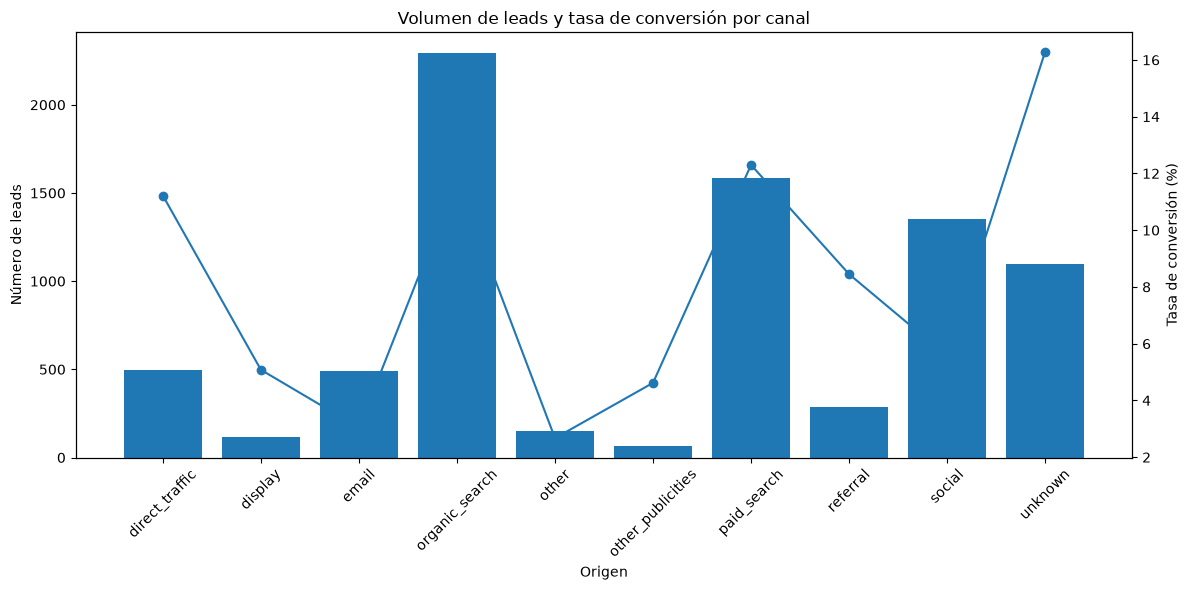

In [230]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(conversion_origen.index, conversion_origen["leads"])

ax1.set_xlabel("Origen")
ax1.set_ylabel("Número de leads")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()

ax2.plot(conversion_origen.index, conversion_origen["tasa_conversion"], marker="o")

ax2.set_ylabel("Tasa de conversión (%)")

plt.title("Volumen de leads y tasa de conversión por canal")
plt.tight_layout()
plt.show()

Organic search y paid search destacan por combinar un elevado volumen de leads con tasas de conversión superiores a la media. Social genera un volumen importante de leads, pero presenta una conversión significativamente inferior. El origen unknown muestra una tasa elevada, aunque su interpretación está limitada por la falta de información sobre la procedencia de los leads.

In [221]:
# Segmento de negocio

conversion_segmento = (df_marketing.groupby("business_segment").agg(
        leads=("mql_id", "count"),
        convertidos=("convertido", "sum")
    )
)

conversion_segmento["tasa_conversion"] = (conversion_segmento["convertidos"] / conversion_segmento["leads"] * 100).round(2)

conversion_segmento.sort_values("tasa_conversion", ascending=False)

,leads,convertidos,tasa_conversion
business_segment,,,
air_conditioning,3,3,100.00
audio_video_electronics,64,64,100.00
baby,10,10,100.00
bags_backpacks,22,22,100.00
bed_bath_table,22,22,100.00
books,9,9,100.00
car_accessories,77,77,100.00
computers,34,34,100.00
construction_tools_house_garden,69,69,100.00


Si business_segment solo está informado para los leads convertidos, por tanto, se descarta para medir conversión. 

In [222]:
df_marketing.groupby("convertido")[["lead_type", "lead_behaviour_profile", "business_type"]].count()

,lead_type,lead_behaviour_profile,business_type
convertido,,,
False,0,0,0
True,836,665,832


Las tres variables tienen el mismo problema que business_segment: solo están informadas para los leads que se convierten.

In [223]:
# Conversión del lead según el momento de captación

df_marketing["first_contact_date"].agg(["min", "max"])

min   2017-06-14
max   2018-05-31
Name: first_contact_date, dtype: datetime64[us]

16. ¿Cómo evoluciona la captación y conversión de leads en el tiempo?

In [224]:
# Evolución del volumen de captación

df_marketing["mes_contacto"] = (df_marketing["first_contact_date"].dt.to_period("M"))

In [225]:
leads_mensuales = (df_marketing.groupby("mes_contacto").agg(
        leads=("mql_id", "count"),
        convertidos=("convertido", "sum")
    )
)

leads_mensuales["tasa_conversion"] = (leads_mensuales["convertidos"] / leads_mensuales["leads"] * 100).round(2)

leads_mensuales

,leads,convertidos,tasa_conversion
mes_contacto,,,
2017-06,4,0,0.00
2017-07,239,2,0.84
2017-08,386,9,2.33
2017-09,312,7,2.24
2017-10,416,14,3.37
2017-11,445,18,4.04
2017-12,200,11,5.50
2018-01,1141,152,13.32
2018-02,1028,149,14.49


In [226]:
# Tiempo de conversión de los leads

df_marketing["dias_conversion"] = (df_marketing["won_date"] - df_marketing["first_contact_date"]).dt.days

In [227]:
df_marketing.loc[df_marketing["convertido"], "dias_conversion"].describe()

count   842.00
mean     48.44
std      75.33
min      -2.00
25%       5.00
50%      14.00
75%      54.75
max     427.00
Name: dias_conversion, dtype: float64

La distribución del tiempo de conversión es muy amplia: Mediana: 14 días. Media: 48,44 días. 25 % convierte en 5 días o menos. 75 % convierte en 55 días aproximadamente o menos. Máximo: 427 días.
La tasa de conversión mensual está afectada por el tiempo disponible para convertir.

In [228]:
df_marketing.loc[df_marketing["dias_conversion"] < 0, ["mql_id", "first_contact_date", "won_date", "dias_conversion"]]

,mql_id,first_contact_date,won_date,dias_conversion
6357,b91cf8812365f50ff4bda4bcd6206b05,2018-03-08,2018-03-06 19:38:55,-2.00


Es un único caso y la diferencia es pequeña: first_contact_date figura como 8 de marzo, mientras que won_date es el 6 de marzo a las 19:38. Parece más bien una inconsistencia puntual en el registro de fechas que un patrón.

In [229]:
leads_mensuales.loc[: "2018-03"]

,leads,convertidos,tasa_conversion
mes_contacto,,,
2017-06,4,0,0.00
2017-07,239,2,0.84
2017-08,386,9,2.33
2017-09,312,7,2.24
2017-10,416,14,3.37
2017-11,445,18,4.04
2017-12,200,11,5.50
2018-01,1141,152,13.32
2018-02,1028,149,14.49


Entre julio y diciembre de 2017, la tasa de conversión aumenta progresivamente desde 0,84 % hasta 5,50 %. A partir de enero de 2018 se produce un salto muy importante, situándose la conversión en:
Enero: 13,32 %
Febrero: 14,49 %
Marzo: 14,22 %
El análisis temporal no demuestra por sí solo la causa de esta mejora. Puede deberse a cambios en la captación, en los canales utilizados, en la calidad de los leads o en el propio proceso comercial.

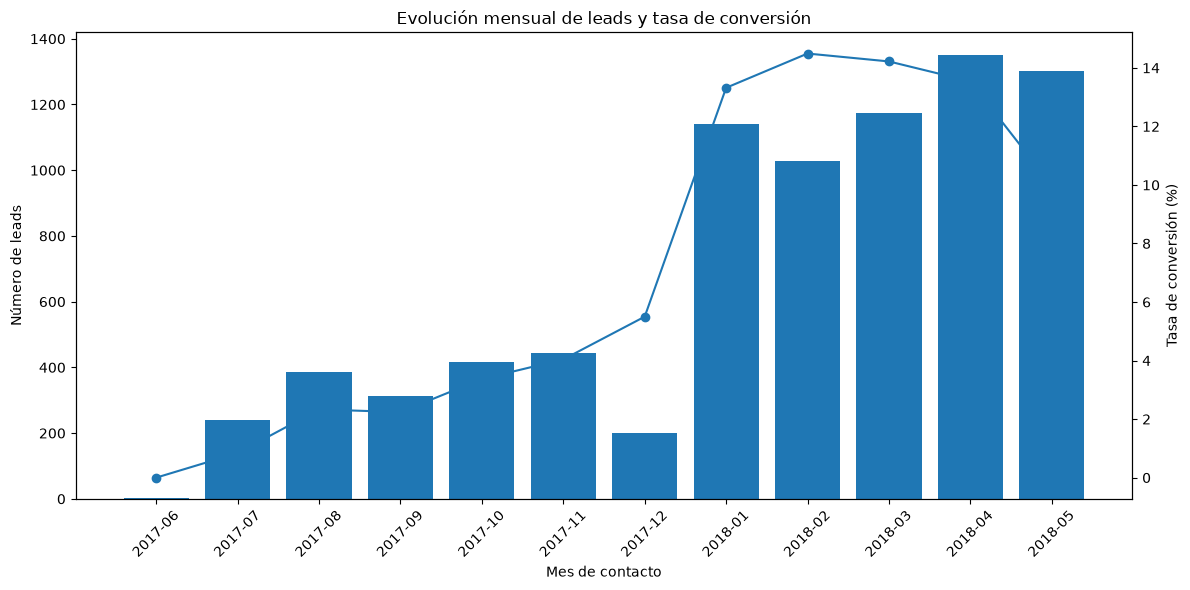

In [231]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(leads_mensuales.index.astype(str), leads_mensuales["leads"])

ax1.set_xlabel("Mes de contacto")
ax1.set_ylabel("Número de leads")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()

ax2.plot(leads_mensuales.index.astype(str), leads_mensuales["tasa_conversion"], marker="o")

ax2.set_ylabel("Tasa de conversión (%)")

plt.title("Evolución mensual de leads y tasa de conversión")
plt.tight_layout()
plt.show()

La captación de leads experimenta un crecimiento notable a partir de enero de 2018, acompañado de un aumento significativo de la tasa de conversión, que se mantiene alrededor del 14 % hasta marzo. Esto sugiere una mejora en la capacidad de captación y conversión respecto a 2017. La evolución de abril y mayo debe interpretarse con cautela, ya que los leads más recientes han dispuesto de menos tiempo para convertirse.